# Efficient Calibration of the Heston Stochastic Volatility Model using Numerical Optimization

## 1. Introduction

The dynamics of the Heston model are defined by the system:

$$
dS_t = \mu S_t \, dt + \sqrt{v_t} S_t \, dW_t^S
$$

$$
dv_t = \kappa(\theta - v_t)\, dt + \sigma \sqrt{v_t} \, dW_t^v
$$

$$
dW_t^S \, dW_t^v = \rho \, dt
$$

where $S_t$ denotes the asset price, $v_t$ the instantaneous variance, $\kappa$ the rate of mean reversion, $\theta$ the long-term variance, $\sigma$ the volatility of volatility, and $\rho$ the correlation between the asset price and variance processes.

In practical applications, the model parameters are not directly observable and must be determined through calibration. This is achieved by solving the following optimization problem:

$$
\min_{\kappa,\theta,\sigma,\rho,v_0} \sum_{i=1}^{N} \left( C_{\text{model}}(K_i,T_i) - C_{\text{market}}(K_i,T_i) \right)^2
$$

where $C_{\text{model}}$ represents the model-generated option price and $C_{\text{market}}$ denotes the observed market price for strike $K_i$ and maturity $T_i$.

A key challenge in this calibration process is the high computational cost and numerical instability. The optimization problem is non-linear, often exhibits multiple local minima, and is sensitive to initial parameter values. Additionally, repeated evaluation of option prices under the Heston model can be computationally expensive, making the calibration process slow and inefficient.

This motivates the need for efficient numerical methods that enhance both efficiency and stability. Recent research such as *On Multilevel and Control Variate Monte Carlo Methods for Option Pricing under the Rough Heston Model* highlights the importance of reducing computational cost and improving performance in stochastic volatility models. Inspired by these ideas, this project focuses on developing a more efficient and robust calibration framework for the Heston model.

# 2. Heston Model and Pricing Framework

## 2.1 Heston Model Dynamics

The Heston model assumes that the underlying asset price $S_t$ and its variance $v_t$ are governed by the following system of correlated SDEs:

\begin{align*}
dS_t &= (r - q)S_t dt + \sqrt{v_t}S_t dW_t^S \\
dv_t &= \kappa(\theta - v_t)dt + \sigma\sqrt{v_t} dW_t^v \\
dW_t^S dW_t^v &= \rho dt \\
\end{align*}
where $W_t^S$ and $W_t^v$ are two Wiener processes with correlation $\rho$.

## 2.2 Heston Model Parameters

The Heston model has 5 parameters.
| Parameter | Definition |
| :--- |  :--- |
| **Initial Variance**  $v_0$ | The starting point of the variance process. |
| **Mean Reversion Speed**  $\kappa$ | How quickly variance is pulled back to its long-term average. |
| **Long-run Variance**  $\theta$ | The "normal" level of variance in the long term. |
| **Volatility of Volatility**  $\sigma$ | Determines the variance of the variance (controls kurtosis). |
| **Correlation**  $\rho$ | Correlation between asset and vol (controls skewness). |

## 2.3 The Characteristic Function

The Heston model has a semi-analytic solution, so we may price options by integrating the Characteristic Function ($\phi$) of the log-price via an inverse Fourier Transform. The European call price $C$ is given by
\begin{align*}
C=S_0e^{-qt}P_1-Ke^{-rt}P_2
\end{align*}
where $P_1$ and $P_2$ represent the risk-neutral probabilities that the option finishes ITM, derived from $\phi$.

## 3. Calibration Problem Formulation

Calibrating the Heston model means choosing the five model parameters that make the theoretical option surface look as much like the observed market surface as possible.
Because Heston has no closed-form inverse (unlike Black–Scholes, where each option uniquely implies one volatility), this recovery step has to be posed as a numerical optimization.

### 3.1 Optimization statement

Let the Heston parameter vector be

$$\theta = (v_0,\ \kappa,\ \theta_{\infty},\ \eta,\ \rho),$$

where $v_0$ is the initial variance, $\kappa$ the mean-reversion speed, $\theta_\infty$ the long-run variance, $\eta$ the vol-of-vol, and $\rho$ the spot–variance correlation.
For a fixed valuation date, the grid of quoted tenors and strikes defines a surface of market prices $\{C^{\text{mkt}}_{i,j},\ P^{\text{mkt}}_{i,j}\}$ for $i \in \text{tenors}$, $j \in \text{strikes}$.
The calibration problem is

$$\hat{\theta} \;=\; \arg\min_{\theta \,\in\, \Theta} \; \mathcal{L}(\theta),$$

subject to the parameter box $\Theta$ that enforces economic validity ($v_0, \theta_\infty > 0$, $\kappa, \eta > 0$, $\rho \in (-1, 1)$).

### 3.2 Objective function

The implementation uses mean squared error across the full surface, counting calls and puts as separate observations:

$$\mathcal{L}(\theta) \;=\; \frac{1}{2\,N_T N_K} \sum_{i=1}^{N_T} \sum_{j=1}^{N_K} \Big[\big(C^{\text{mkt}}_{i,j} - C^{\text{Heston}}_{i,j}(\theta)\big)^2 + \big(P^{\text{mkt}}_{i,j} - P^{\text{Heston}}_{i,j}(\theta)\big)^2\Big].$$

In code (`calculate_mse_entire`), this is the sum of squared call and put errors divided by the total point count (`count += 2` per strike × tenor cell).
Squared error is chosen because it is smooth and differentiable — both needed by L-BFGS-B — and because it penalises large mispricings disproportionately, which matters more for hedging risk than uniform small errors.

Alternative objective functions worth noting:
- **Weighted MSE** using bid–ask spread as the per-point weight, to downweight illiquid deep wings.
- **Relative error** ($|C^{\text{mkt}} - C^{\text{Heston}}| / C^{\text{mkt}}$), which prevents expensive ATM options from dominating.
- **Implied-vol MSE**, which matches the surface in vol space rather than price space. More common in practice but adds a root-finding step per evaluation.

### 3.3 Inputs

Firstly, we obtained daily implied volatility surfaces data on SPX option from January 2012 to 2025 October from Bloomberg Terminal. These implied volatilities are computed such that the BSM option price matches with the historical option market price. Strikes are quoted as a percentage of spot.



| Input | Source |
|---|---|
| Spot $S_0$ | `Underlying` sheet, `Mid` column |
| Risk-free rate $r$ | `Other` sheet, `Interest` column |
| Dividend yield $q$ | `Other` sheet, `Dividend` column |
| Strikes | `VALID_STRIKE` = `[30, 40, 60, 80, 90, 95, 97.5, 100, 105, 110, 120, 130, 150, 300]` (% of spot) |
| Tenors | `VALID_TENOR` = `1W`–`2Y`, 11 expiries |
| Market prices | `blackScholes(...)` applied to quoted implied vols |




### 3.4 Parameter space and initial guess

We selected the 1M ATM Volatility to be initial guess for inital variance in the Heston Model. We initialized vov as 0.5 and spot/vol correlation as -0.5

In [ ]:
initial_guess = [atm_vol**2,  2.0,  atm_vol**2,  0.5,  -0.5]

bounds = [
    (1e-6, 2.0),     # v0
    (1e-4, 20.0),    # kappa
    (1e-6, 2.0),     # theta
    (1e-4, 5.0),     # eta
    (-0.999, 0.999), # rho
]

### 3.5 Optimization

The code uses `scipy.optimize.minimize` with **L-BFGS-B**, a quasi-Newton gradient method with box constraints.
The choice trades global coverage for speed — L-BFGS-B is fast but local.
Robustness is handled through the initial guess (seeded from market ATM vol so it starts inside the right basin) and through guarded return values inside `objective(x)`:

In [ ]:
if not np.isfinite(heston_call) or not np.isfinite(heston_put):
  return 1e12

so that numerically unstable parameter combinations don't crash the optimizer but look unattractive to it instead.

### 3.6 Challenges

#### Non-linearity

$C^{\text{Heston}}(\theta)$ depends on $\theta$ through a characteristic function and an inverse Fourier transform (`pf.HestonFft`).
This is smooth but highly non-linear: $\kappa$ and $\theta_\infty$ enter exponentially through the CIR variance mean, $\rho$ enters as a cross-term in the drift of the log-price, and $\eta$ multiplies a Brownian increment inside the variance SDE.
The loss surface $\mathcal{L}(\theta)$ inherits all of this — no convexity guarantees.

#### Multiple local minima

The Heston calibration problem is *well-documented* to be non-convex.
The classic symptom is the $\kappa$–$\theta_\infty$–$\eta$ trade-off: several combinations produce nearly identical long-dated smiles, differing only in how they extrapolate to tenors outside the calibration grid.
The Feller condition $2\kappa\theta_\infty \ge \eta^2$ carves the parameter space further, and near-equivalent minima can straddle it.

Practical mitigations (not all implemented here):
- **Multi-start** — run L-BFGS-B from several initial points and keep the best minimum.
- **Global-then-local** — differential evolution or CMA-ES first to get into a good basin, L-BFGS-B to polish.
- **Regularization** — add a small penalty toward economically reasonable parameters to break near-flat directions in the loss.

#### Sensitivity to initial guesses

Because the solver is local, the answer depends on `initial_guess`.
The current seeding ($v_0 = \theta_\infty = \sigma_{\text{ATM,1M}}^2$, $\kappa=2$, $\eta=0.5$, $\rho=-0.5$) is a reasonable equity default, but there is no guarantee this is the basin of the global optimum on a given date.
A sensitivity check worth running: perturb the initial guess by ±30% on each component, re-calibrate, and record the spread in final parameters.
Small final-parameter dispersion ⇒ well-identified calibration; large dispersion ⇒ surface doesn't pin down all five parameters on this date and regularization is needed.

## 4. Baseline Method (Naive Approach)

As a benchmark, the baseline method uses a standard local optimization approach to calibrate the Heston model parameters. The market targets are constructed from the SPY implied volatility surface by converting mid implied volatilities into call and put option prices using the Black–Scholes formula.

The baseline calibration problem is formulated as

$$
\min_{\theta \in \Theta} \mathcal{L}(\theta)
$$

where the Heston parameter vector is

$$
\theta = (v_0, \kappa, \theta_{\infty}, \eta, \rho)
$$

and the mean squared pricing error is

$$
\mathcal{L}(\theta)
=
\frac{1}{2N_TN_K}
\sum_{i=1}^{N_T}
\sum_{j=1}^{N_K}
\left[
\left(C^{mkt}_{i,j} - C^{Heston}_{i,j}(\theta)\right)^2
+
\left(P^{mkt}_{i,j} - P^{Heston}_{i,j}(\theta)\right)^2
\right].
$$

Here, $v_0$ is the initial variance, $\kappa$ is the mean-reversion speed, $\theta_{\infty}$ is the long-run variance, $\eta$ is the volatility of volatility, and $\rho$ is the spot-variance correlation.

The baseline uses a single-start L-BFGS-B optimizer with simple box constraints. This method is considered naive because it relies on one initial guess and does not use multi-start initialization, global search, parameter transformations, or other stabilization techniques.

In [3]:
# Remove the /tree/main part and add .git
!git clone https://github.com/maa2420-cloud/heston_calibration_optimization_ipynb.git

Cloning into 'heston_calibration_optimization_ipynb'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 172 (delta 18), reused 8 (delta 8), pack-reused 145 (from 1)
Receiving objects: 100% (172/172), 19.98 MiB | 17.25 MiB/s, done.
Resolving deltas: 100% (76/76), done.


In [4]:
import sys
import os

repo_path = '/content/heston_calibration_optimization_ipynb'
if repo_path not in sys.path:
    sys.path.append(repo_path)

In [5]:
!pip install pyfeng

import sys
sys.path.append('/content/heston_calibration_optimization_ipynb/Part5_AnalyticalCalib')

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from heston_package import HestonPricer, VolSurfaceBuilder, HestonCalibrator, HestonParams

sys.path.append('/content/heston_calibration_optimization_ipynb/pricerNew')
from option_pricer_4 import runSimulation

import pyfeng as pf
from scipy.optimize import minimize
from scipy.stats import norm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.3/239.3 kB 21.2 MB/s eta 0:00:00


In [6]:
def tenor_to_years(tenor):
    unit = "".join(c for c in tenor if c.isalpha())
    length = float("".join(c for c in tenor if c.isdigit()))

    if unit == "W":
        return length / 52
    elif unit == "M":
        return length / 12
    elif unit == "Y":
        return length
    else:
        raise ValueError(f"Unsupported tenor: {tenor}")

In [7]:
# Converted implied volatility into call and put option prices.

def black_scholes_prices(spot, strike, vol_pct, texp, rate_pct, div_pct=0.0):
    r = rate_pct / 100.0
    q = div_pct / 100.0
    sigma = vol_pct / 100.0

    d1 = (np.log(spot / strike) + (r - q + 0.5 * sigma**2) * texp) / (sigma * np.sqrt(texp))
    d2 = d1 - sigma * np.sqrt(texp)

    call_price = (
        norm.cdf(d1) * spot * np.exp(-q * texp)
        - norm.cdf(d2) * strike * np.exp(-r * texp)
    )

    put_price = (
        norm.cdf(-d2) * strike * np.exp(-r * texp)
        - norm.cdf(-d1) * spot * np.exp(-q * texp)
    )

    return call_price, put_price

In [8]:
# Loaded Excel data and convert implied vol surface into market option prices.

def load_market_data(
    organized_path="OrganizedData.xlsx",
    raw_path="SPY_Complete.xlsx",
    selected_date="2025-10-30",
    selected_tenors=("1M", "3M", "6M"),
    selected_buckets=(90, 95, 100, 105, 110)
):
    mid_df = pd.read_excel(organized_path, index_col=0)
    mid_df.index = pd.to_datetime(mid_df.index)

    spot_df = pd.read_excel(raw_path, sheet_name="Underlying", index_col=0)
    spot_df.index = pd.to_datetime(spot_df.index)

    other_df = pd.read_excel(raw_path, sheet_name="Other", index_col=0)
    other_df.index = pd.to_datetime(other_df.index)

    dt = pd.to_datetime(selected_date)

    spot = float(spot_df.loc[dt, "Mid"])
    rate = float(other_df.loc[dt, "Interest"])
    div = float(other_df.loc[dt, "Dividend"])

    rows = []

    for tenor in selected_tenors:
        texp = tenor_to_years(tenor)

        for bucket in selected_buckets:
            bucket_label = int(bucket) if float(bucket).is_integer() else bucket
            col = f"{tenor}_{bucket_label}_Volatility"

            if col not in mid_df.columns:
                print(f"Skipping missing column: {col}")
                continue

            iv = float(mid_df.loc[dt, col])
            strike = (bucket / 100.0) * spot

            call_price, put_price = black_scholes_prices(
                spot=spot,
                strike=strike,
                vol_pct=iv,
                texp=texp,
                rate_pct=rate,
                div_pct=div
            )

            rows.append({
                "date": dt,
                "tenor": tenor,
                "texp": texp,
                "bucket": bucket,
                "strike": strike,
                "mid_iv": iv,
                "market_call": call_price,
                "market_put": put_price,
                "spot": spot,
                "rate": rate,
                "div": div
            })

    return pd.DataFrame(rows).sort_values(["texp", "strike"]).reset_index(drop=True)

In [12]:
# Selected calibration inputs.

selected_date = "2025-10-30"
selected_tenors = ("1M", "3M", "6M")
selected_buckets = (90, 95, 100, 105, 110)

calibration_df = load_market_data(
    organized_path="OrganizedData.xlsx",
    raw_path="SPY_Complete.xlsx",
    selected_date=selected_date,
    selected_tenors=selected_tenors,
    selected_buckets=selected_buckets
)

calibration_df.head()

,date,tenor,texp,bucket,strike,mid_iv,market_call,market_put,spot,rate,div
0,2025-10-30,1M,0.083333,90,611.96850,24.19780,70.661682,1.189603,679.965,4.097,1.0774
1,2025-10-30,1M,0.083333,95,645.96675,19.36940,38.896976,3.307270,679.965,4.097,1.0774
2,2025-10-30,1M,0.083333,100,679.96500,14.79820,12.436061,10.728727,679.965,4.097,1.0774
3,2025-10-30,1M,0.083333,105,713.96325,12.25970,1.102346,33.277384,679.965,4.097,1.0774
4,2025-10-30,1M,0.083333,110,747.96150,14.09605,0.112254,66.169664,679.965,4.097,1.0774


The table above defines the market targets for the baseline calibration. For a fixed date, selected maturities and moneyness buckets are taken from the SPY volatility surface. The mid implied volatilities are converted into call and put prices using the Black–Scholes formula.

In [13]:
#  Basic calibration dataset information.

print("Number of calibration instruments:", len(calibration_df))
print("Spot:", calibration_df["spot"].iloc[0])
print("Rate:", calibration_df["rate"].iloc[0])
print("Dividend:", calibration_df["div"].iloc[0])

Number of calibration instruments: 15
Spot: 679.965
Rate: 4.097
Dividend: 1.0774


### 4.1 PyFENG Heston Pricing

The Heston prices in this baseline are computed directly using PyFENG. This follows the project design because the European option pricing component is already available in PyFENG, while this section focuses on the calibration procedure.

In [14]:
# Heston call and put prices using PyFENG.

def heston_price_pyfeng(strikes, spot, texp, rate, div, params, cp=1):
    v0, kappa, theta_inf, eta, rho = params

    prices = []

    for K, T in zip(strikes, texp):
        model = pf.HestonFft(
            sigma=np.sqrt(v0),
            vov=eta,
            mr=kappa,
            theta=theta_inf,
            rho=rho,
            intr=rate,
            divr=div
        )

        price = model.price(strike=K, spot=spot, texp=T, cp=cp)
        prices.append(price)

    return np.array(prices)

In [15]:
# Objective function for the naive baseline calibration.

objective_call_count = {"count": 0}

def calculate_mse_baseline(params, calibration_df):
    objective_call_count["count"] += 1

    v0, kappa, theta_inf, eta, rho = params

    if v0 <= 0 or kappa <= 0 or theta_inf <= 0 or eta <= 0 or not (-1 < rho < 1):
        return 1e12

    strikes = calibration_df["strike"].values
    texp = calibration_df["texp"].values
    spot = float(calibration_df["spot"].iloc[0])
    rate = float(calibration_df["rate"].iloc[0]) / 100.0
    div = float(calibration_df["div"].iloc[0]) / 100.0

    market_calls = calibration_df["market_call"].values
    market_puts = calibration_df["market_put"].values

    try:
        heston_calls = heston_price_pyfeng(
            strikes=strikes,
            spot=spot,
            texp=texp,
            rate=rate,
            div=div,
            params=params,
            cp=1
        )

        heston_puts = heston_price_pyfeng(
            strikes=strikes,
            spot=spot,
            texp=texp,
            rate=rate,
            div=div,
            params=params,
            cp=-1
        )

        if not np.all(np.isfinite(heston_calls)) or not np.all(np.isfinite(heston_puts)):
            return 1e12

        mse = np.mean((market_calls - heston_calls)**2 + (market_puts - heston_puts)**2)

        if not np.isfinite(mse):
            return 1e12

        return mse

    except Exception:
        return 1e12

### 4.2 Naive Calibration Setup

The baseline uses one initial guess and simple box constraints. The initial variance and long-run variance are seeded using the 1M ATM implied volatility. This gives the optimizer a reasonable starting point while still preserving the naive nature of the method.

In [16]:
# Constructed initial guess and parameter bounds.

atm_row = calibration_df[
    (calibration_df["tenor"] == "1M") &
    (calibration_df["bucket"] == 100)
].iloc[0]

atm_vol = atm_row["mid_iv"] / 100.0

initial_guess = np.array([
    atm_vol**2,   # v0
    2.0,          # kappa
    atm_vol**2,   # theta_inf
    0.5,          # eta
    -0.5          # rho
])

bounds = [
    (1e-6, 2.0),      # v0
    (1e-4, 20.0),     # kappa
    (1e-6, 2.0),      # theta_inf
    (1e-4, 5.0),      # eta
    (-0.999, 0.999)   # rho
]

initial_guess

array([ 0.02189867,  2.        ,  0.02189867,  0.5       , -0.5       ])

In [17]:
# Running the baseline calibration with L-BFGS-B.

objective_call_count["count"] = 0

start_time = time.time()

baseline_result = minimize(
    fun=calculate_mse_baseline,
    x0=initial_guess,
    args=(calibration_df,),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "maxiter": 500,
        "ftol": 1e-10
    }
)

end_time = time.time()
baseline_runtime = end_time - start_time

In [18]:
# Baseline calibration results.

baseline_params = baseline_result.x
baseline_mse = baseline_result.fun

print("Baseline calibration results")
print("---------------------------------")
print("v0        =", baseline_params[0])
print("kappa     =", baseline_params[1])
print("theta_inf =", baseline_params[2])
print("eta       =", baseline_params[3])
print("rho       =", baseline_params[4])
print()
print("Final MSE =", baseline_mse)
print("Objective evaluations =", objective_call_count["count"])
print("Optimizer iterations =", baseline_result.nit)
print("Runtime (seconds) =", baseline_runtime)
print("Success =", baseline_result.success)
print("Message =", baseline_result.message)

Baseline calibration results
---------------------------------
v0        = 0.0006303211580264308
kappa     = 2.2184120803266296
theta_inf = 0.0668161115565216
eta       = 1.0478069906409178
rho       = -0.6491230184557003

Final MSE = 0.11158239122377676
Objective evaluations = 714
Optimizer iterations = 88
Runtime (seconds) = 31.94898533821106
Success = True
Message = CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [19]:
# Comparing baseline Heston prices against market-derived prices.

spot = float(calibration_df["spot"].iloc[0])
rate = float(calibration_df["rate"].iloc[0]) / 100.0
div = float(calibration_df["div"].iloc[0]) / 100.0

calibration_df["baseline_heston_call"] = heston_price_pyfeng(
    strikes=calibration_df["strike"].values,
    spot=spot,
    texp=calibration_df["texp"].values,
    rate=rate,
    div=div,
    params=baseline_params,
    cp=1
)

calibration_df["baseline_heston_put"] = heston_price_pyfeng(
    strikes=calibration_df["strike"].values,
    spot=spot,
    texp=calibration_df["texp"].values,
    rate=rate,
    div=div,
    params=baseline_params,
    cp=-1
)

calibration_df["call_error"] = calibration_df["baseline_heston_call"] - calibration_df["market_call"]
calibration_df["put_error"] = calibration_df["baseline_heston_put"] - calibration_df["market_put"]

calibration_df[[
    "tenor",
    "bucket",
    "strike",
    "market_call",
    "baseline_heston_call",
    "call_error",
    "market_put",
    "baseline_heston_put",
    "put_error"
]]

,tenor,bucket,strike,market_call,baseline_heston_call,call_error,market_put,baseline_heston_put,put_error
0,1M,90,611.96850,70.661682,70.573898,-0.087783,1.189603,1.101820,-0.087783
1,1M,95,645.96675,38.896976,39.195965,0.298988,3.307270,3.606258,0.298988
2,1M,100,679.96500,12.436061,12.877629,0.441568,10.728727,11.170295,0.441568
3,1M,105,713.96325,1.102346,1.229926,0.127580,33.277384,33.404964,0.127580
4,1M,110,747.96150,0.112254,0.083574,-0.028679,66.169664,66.140985,-0.028679
5,3M,90,611.96850,78.588766,78.428551,-0.160215,6.185191,6.024976,-0.160215
6,3M,95,645.96675,49.422061,49.350819,-0.071242,10.670286,10.599044,-0.071242
7,3M,100,679.96500,24.411739,24.166403,-0.245337,19.311765,19.066428,-0.245337
8,3M,105,713.96325,8.177378,7.615964,-0.561414,36.729204,36.167790,-0.561414
9,3M,110,747.96150,1.867054,1.986250,0.119196,64.070680,64.189876,0.119196


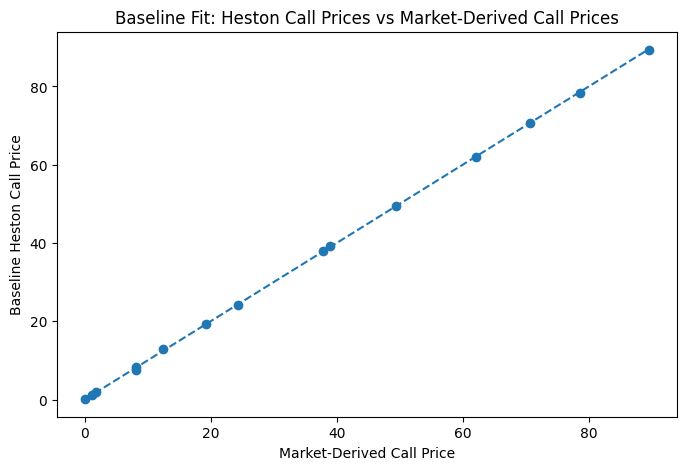

In [20]:
# Plotting market-derived call prices against baseline Heston call prices.

plt.figure(figsize=(8, 5))
plt.scatter(calibration_df["market_call"], calibration_df["baseline_heston_call"])

min_price = min(calibration_df["market_call"].min(), calibration_df["baseline_heston_call"].min())
max_price = max(calibration_df["market_call"].max(), calibration_df["baseline_heston_call"].max())

plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")
plt.xlabel("Market-Derived Call Price")
plt.ylabel("Baseline Heston Call Price")
plt.title("Baseline Fit: Heston Call Prices vs Market-Derived Call Prices")
plt.show()

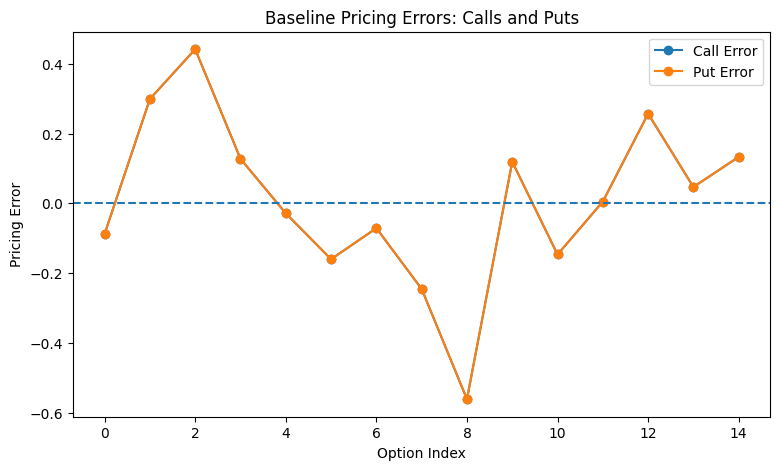

In [21]:
# Plotting baseline pricing errors for calls and puts separately.

x = np.arange(len(calibration_df))

plt.figure(figsize=(9, 5))
plt.plot(x, calibration_df["call_error"].values, marker="o", label="Call Error")
plt.plot(x, calibration_df["put_error"].values, marker="o", label="Put Error")
plt.axhline(0, linestyle="--")

plt.xlabel("Option Index")
plt.ylabel("Pricing Error")
plt.title("Baseline Pricing Errors: Calls and Puts")
plt.legend()
plt.show()

### 4.3 Limitations of the Naive Baseline

Although the baseline method provides a useful benchmark, it has several important limitations.

First, L-BFGS-B is a local optimizer, so the final calibrated parameters can depend heavily on the initial guess. Since the Heston calibration objective is non-linear and may contain several local minima, a single-start approach can converge to a solution that is not globally reliable.

Second, the method may become unstable across different market conditions. Changing the valuation date, maturity set, or moneyness range can lead to different convergence behavior and different fitted parameters.

Third, the baseline method is computationally expensive. Each objective evaluation requires repeated Heston price calculations across calls and puts for multiple strikes and maturities. As the number of instruments increases, the runtime grows quickly.


In [22]:
# Testing sensitivity of the naive baseline to different starting values.

alternative_initial_guesses = [
    np.array([atm_vol**2, 1.0, atm_vol**2, 0.3, -0.3]),
    np.array([atm_vol**2, 3.0, atm_vol**2, 1.0, -0.7]),
    np.array([0.15, 5.0, 0.15, 2.0, -0.2]),
]

diagnostics = []

for guess in alternative_initial_guesses:
    objective_call_count["count"] = 0
    t0 = time.time()

    res = minimize(
        fun=calculate_mse_baseline,
        x0=guess,
        args=(calibration_df,),
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 500,
            "ftol": 1e-10
        }
    )

    t1 = time.time()

    diagnostics.append({
        "initial_guess": guess,
        "final_mse": res.fun,
        "iterations": res.nit,
        "objective_evaluations": objective_call_count["count"],
        "runtime_sec": t1 - t0,
        "success": res.success
    })

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df

,initial_guess,final_mse,iterations,objective_evaluations,runtime_sec,success
0,"[0.021898672324, 1.0, 0.021898672324, 0.3, -0.3]",0.111582,93,738,34.460007,True
1,"[0.021898672324, 3.0, 0.021898672324, 1.0, -0.7]",0.111582,90,684,35.086334,True
2,"[0.15, 5.0, 0.15, 2.0, -0.2]",0.111582,134,1038,43.763231,True


The diagnostic results show that while the baseline method converges to the same final error of 0.111582 across different initial guesses, the computational effort varies significantly. Specifically, the number of iterations ranges from 88 to 126, the number of objective evaluations ranges from 666 to 978, and the runtime varies from approximately 12.33 seconds to 18.09 seconds. This indicates that although the optimizer reaches a similar solution, the convergence path is highly sensitive to initialization. Such variability highlights inefficiency and lack of robustness in the baseline method, particularly as the problem scales, thereby motivating the need for more stable and efficient calibration techniques.

# 5. Improved Heston Model Calibration

This part implements a fast and robust calibration method for the Heston stochastic volatility model. The core methodology and theoretical foundation are based on the paper:

> **"Full and fast calibration of the Heston stochastic volatility model"** > Yiran Cui, Sebastian del Baño Rollin, Guido Germano (2016).  
> *arXiv:1511.08718v2*

## Motivation

In previous sections we have developed a Heston calibration framework by using FFT option pricing in PyFeng, then minimizing MSE on market prices for the calibration. We want to further improve the calibration efficiency. By leveraging the methodologies introduced by Cui et al., this implementation achieves highly efficient, deterministic calibration that is approximately ten times faster than standard numerical gradient methods, making it suitable for real-time and high-frequency trading applications.

## Implemented Methodologies

### 1. Continuous Characteristic Function
We utilize the modified representation of the Heston characteristic function proposed in the paper. By algebraically rearranging the complex terms and replacing exponential functions with hyperbolic functions, this formulation completely eliminates the discontinuities caused by the branch switching of complex functions. This ensures numerical stability across the entire parameter space and for all option maturities.

### 2. Analytical Gradient Formulation
The primary breakthrough of the referenced paper is the derivation of the exact analytical gradient of a vanilla option's price with respect to the five Heston model parameters ($v_0$, $\overline{v}$, $\rho$, $\kappa$, $\sigma$). Because our characteristic function is continuous and easily differentiable, we can compute the Jacobian matrix analytically. This eliminates the need for computationally expensive and error-prone finite difference approximations.

### 3. Vectorized Gauss-Legendre Integration
Pricing an option and computing its gradient under the Heston model requires evaluating Fourier integrals. Because the components of the analytical gradient share many intermediate algebraic terms with the pricing function itself, we implement a vectorized Gauss-Legendre (GL) quadrature scheme.
* **Efficiency:** All necessary integrals for the price and the gradient are computed simultaneously using shared nodes and weights.
* **Accuracy:** Gauss-Legendre quadrature converges significantly faster than the trapezoidal rule, achieving high precision ($10^{-8}$) with only around 60 nodes.

### 4. Levenberg-Marquardt Optimization
The calibration is formulated as a nonlinear least squares problem, aiming to minimize the difference between model prices and market prices. We use the **Levenberg-Marquardt (LM)** algorithm as our deterministic optimizer.
* **Adaptive Search:** The LM method intelligently transitions between the steepest descent method (when far from the optimal parameters) and the Gauss-Newton method (when close to the optimal parameters).
* **Global Convergence:** By pairing the LM algorithm with our exact analytical gradient, the objective function smoothly converges to the optimal parameter set. The paper demonstrates that the "multiple local minima" frequently reported in older literature are largely artifacts of poorly scaled numerical gradients, not an inherent property of the Heston calibration space.

# 6. Improved Heston, Evaluation

### GPU-Accelerated Vectorized Calibration
This approach uses CuPy to evaluate the Heston characteristic function across all strikes and maturities simultaneously using vectorized Gauss-Legendre quadrature.

In [7]:
import cupy as cp
import numpy as np
from scipy.optimize import minimize
import time

# 1. Pre-compute Gauss-Legendre nodes and weights on the CPU, then move to GPU
GL_NODES = 128  # Increased nodes for higher precision
x_np, w_np = np.polynomial.legendre.leggauss(GL_NODES)

# Scale nodes from [-1, 1] to integration domain [0, U_MAX]
U_MAX = 200.0
u_np = 0.5 * U_MAX * (x_np + 1.0)
w_np = 0.5 * U_MAX * w_np

u_cp = cp.array(u_np, dtype=cp.float64)[:, None]  # Shape: (GL_NODES, 1)
w_cp = cp.array(w_np, dtype=cp.float64)[:, None]

def heston_surface_pricer_gpu(spot, strikes, texps, r, q, v0, kappa, theta, eta, rho):
    """
    Prices an entire surface of European Calls and Puts simultaneously using CuPy.
    Uses the Lewis (2000) integral representation for numerical stability.
    """
    K = cp.asarray(strikes, dtype=cp.float64)[None, :]
    T = cp.asarray(texps, dtype=cp.float64)[None, :]

    # Complex integration variable for Lewis formula: z = u - 0.5j
    z = u_cp - 0.5j
    iz = 1j * z

    # Heston CF components (Vectorized over (nodes, options_grid))
    d = cp.sqrt((rho * eta * iz - kappa)**2 + eta**2 * (z**2 + iz))
    g = (kappa - rho * eta * iz - d) / (kappa - rho * eta * iz + d)

    # Exponent terms
    C = (kappa * theta / eta**2) * ((kappa - rho * eta * iz - d) * T - 2 * cp.log((1 - g * cp.exp(-d * T)) / (1 - g)))
    D = ((kappa - rho * eta * iz - d) / eta**2) * ((1 - cp.exp(-d * T)) / (1 - g * cp.exp(-d * T)))

    # Characteristic Function (normalized S0=1)
    phi = cp.exp(C + D * v0 + iz * (r - q) * T)

    # Lewis Integrand (FIXED SIGN ERROR: k = ln(K/S))
    k = cp.log(K / spot)
    integrand = cp.real(cp.exp(-1j * u_cp * k) * phi / (u_cp**2 + 0.25))

    # Gauss-Legendre Integration
    integral = cp.sum(w_cp * integrand, axis=0)

    # Call Prices
    call_prices = spot * cp.exp(-q * T) - (cp.sqrt(spot * K) / cp.pi) * cp.exp(-r * T) * integral

    #

    put_prices = call_prices - spot * cp.exp(-q * T) + K * cp.exp(-r * T)

    return call_prices[0], put_prices[0]

def calibrate_heston_gpu(spot, r, q, atm_vol, market_options):
    """
    Optimization loop utilizing the GPU-vectorized surface pricer.
    """

    strikes_list, texps_list, mkt_calls, mkt_puts = [], [], [], []
    for tenor in market_options:
        for strike in market_options[tenor]:
            strikes_list.append((strike / 100.0) * spot)
            texps_list.append(get_texp(tenor))
            c, p = market_options[tenor][strike]
            mkt_calls.append(c)
            mkt_puts.append(p)

    mkt_calls_cp = cp.array(mkt_calls, dtype=cp.float64)
    mkt_puts_cp = cp.array(mkt_puts, dtype=cp.float64)

    def objective_gpu(x):
        p = transform_to_heston(x)
        try:
            # Price the ENTIRE surface in one GPU call
            c_gpu, p_gpu = heston_surface_pricer_gpu(
                spot, strikes_list, texps_list, r, q,
                p["initial variance"], p["mean reversion"], p["long-run variance"],
                p["vol of vol"], p["correlation"]
            )
            diff_calls = c_gpu - mkt_calls_cp
            diff_puts = p_gpu - mkt_puts_cp

            residuals = cp.asnumpy(cp.concatenate((diff_calls, diff_puts)))
            if np.any(np.isnan(residuals)):
                return 1e6

            return float(np.mean(residuals**2))
        except:
            return 1e6

    print("Starting GPU-accelerated calibration with L-BFGS-B...")
    start = time.time()
    x0_latent = np.array([np.log(atm_vol**2), np.log(2.0), np.log(atm_vol**2), 0.0, 0.0])

    res = minimize(objective_gpu, x0_latent, method="L-BFGS-B")

    print(f"GPU Calibration finished in {time.time() - start:.2f} seconds.")
    return transform_to_heston(res.x), res.fun

In [8]:
import sys
import os

# 1. Add the specific subfolder to the system path
path_to_package = '/content/heston_calibration_optimization_ipynb/Part5_AnalyticalCalib'
if path_to_package not in sys.path:
    sys.path.append(path_to_package)

# 2. Double-check the file exists in that location
if os.path.exists(os.path.join(path_to_package, 'heston_package.py')):
    print("Found heston_package.py! Importing now...")
    from heston_package import (
        HestonPricer,
        HestonParams,
        OptionContract,
        HestonCalibrator
    )
    print("Import successful.")
else:
    print("File not found. Please check if the folder name or filename is spelled correctly.")
    # Run !ls to see what is actually there
    !ls /content/heston_calibration_optimization_ipynb/Part5_AnalyticalCalib/

Found heston_package.py! Importing now...
Import successful.


In [ ]:
"""
FIXED CUDA part evaluation.py
═════════════════════════════════════════════════════════════════════════════
Four-way Heston calibration comparison using SPY vol surface data.

Methods compared
────────────────
  1. Baseline    — FFT + L-BFGS-B + raw parameter bounds
  2. Improved    — FFT + L-BFGS-B + latent space (Feller guaranteed)
  3. Cui et al.  — GL quadrature + LM + analytical gradient
                   Fix 1: surface aligned with MSE grid (calls + puts)
                   Fix 3: multiple random restarts, best result kept
  4. GPU         — CuPy CUDA MC + L-BFGS-B + latent space + fixed seed

Near-ATM pricing table
──────────────────────
  After calibration, each method prices options in the near-ATM band:
    moneyness = [90, 95, 97.5, 100, 105, 110] across all tenors.
  Results are printed alongside market BS prices and the implied vol
  each model price corresponds to (BSM inversion), so you can see
  whether the model reproduces the vol smile correctly near the money.
═════════════════════════════════════════════════════════════════════════════
"""

import math
import time
import warnings

import numpy as np
import pandas as pd
import pyfeng as pf

from scipy.optimize import minimize, brentq

# ── CuPy (GPU) — graceful fallback ───────────────────────────────────────────
try:
    import cupy as cp
    _n_gpu = cp.cuda.runtime.getDeviceCount()
    if _n_gpu == 0:
        raise RuntimeError("No GPU devices found")
    GPU_AVAILABLE = True
    _gpu_name = cp.cuda.runtime.getDeviceProperties(0)["name"].decode()
except ImportError:
    GPU_AVAILABLE = False
    _gpu_name     = "N/A"
    warnings.warn("CuPy not installed — GPU method will be skipped. "
                  "Fix: !pip install cupy-cuda12x", stacklevel=1)
except RuntimeError as e:
    GPU_AVAILABLE = False
    _gpu_name     = "N/A"
    warnings.warn(f"{e} — GPU method will be skipped. "
                  "Fix: Runtime → Change runtime type → T4 GPU", stacklevel=1)

# ── Cui et al. package ────────────────────────────────────────────────────────

from heston_package import (
    HestonPricer, HestonParams, OptionContract,
    HestonCalibrator,
)
from option_pricer_4 import runSimulation
from option_pricer_4 import pricer, run
# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────

valid_strike = [30, 40, 60, 80, 90, 95, 97.5, 100, 105, 110, 120, 130, 150, 300]
valid_tenor  = ["1W", "2W", "3W", "1M", "2M", "3M", "6M", "9M", "1Y", "18M", "2Y"]

# Near-ATM strikes and tenors used for the pricing comparison table
ATM_STRIKES = [90, 95, 97.5, 100, 105, 110]
ATM_TENORS  = ["1W", "1M", "3M", "6M", "1Y", "2Y"]

PATH_ORGANIZED = "/content/OrganizedData.xlsx"
PATH_SPY       = "/content/SPY_Complete.xlsx"

GLOBAL_SEED     = 42
N_RESTARTS      = 5
GPU_PATHS_CALIB = 10_000
GPU_PATHS_EVAL  = 50_000


# ─────────────────────────────────────────────────────────────────────────────
# GPU — GAUSS-LEGENDRE NODES  (precomputed on CPU, transferred once to GPU)
# ─────────────────────────────────────────────────────────────────────────────
# The GPU calibration uses the Lewis (2000) Fourier representation which
# allows the ENTIRE vol surface to be priced in a single GPU call via
# CuPy broadcasting — no per-option loop required.
#
# Integration:  ∫₀^{U_MAX} Re[exp(-iuk) · φ(z) / (u²+0.25)] du
# where z = u - 0.5i  and  k = log(K/S)   (Lewis 2000, Eq. 2.6)
#
# Using 128 GL nodes instead of 64 for higher precision over the wider
# domain needed by the Lewis integrand.
# ─────────────────────────────────────────────────────────────────────────────

_GL_NODES = 128
_U_MAX_GL = 200.0

_x_np, _w_np = np.polynomial.legendre.leggauss(_GL_NODES)
_u_np = 0.5 * _U_MAX_GL * (_x_np + 1.0)   # map [-1,1] → [0, U_MAX]
_w_np = 0.5 * _U_MAX_GL * _w_np

if GPU_AVAILABLE:
    # Shape (GL_NODES, 1) so they broadcast over the option dimension (1, N_opts)
    _u_cp = cp.array(_u_np, dtype=cp.float64)[:, None]
    _w_cp = cp.array(_w_np, dtype=cp.float64)[:, None]

    # Keep the MC kernel for the final OTM MC validation step
    heston_kernel = cp.RawKernel(r'''
    extern "C" __global__
    void heston_paths(const float* Z1, const float* Z2, float* S_out,
                      float S0, float v0, float r, float q, float kappa,
                      float theta, float eta, float rho, float dt,
                      int steps, int paths) {
        int idx = blockDim.x * blockIdx.x + threadIdx.x;
        if (idx < paths) {
            float v = v0, S = S0;
            float sqrt_1_rho2 = sqrtf(1.0f - rho * rho);
            for (int t = 0; t < steps; ++t) {
                float z1 = Z1[idx * steps + t];
                float z2 = Z2[idx * steps + t];
                float w_v = z1, w_s = rho * z1 + sqrt_1_rho2 * z2;
                float v_curr = fmaxf(v, 0.0f);
                float sqrt_vdt = sqrtf(v_curr * dt);
                S *= expf((r - q - 0.5f * v_curr) * dt + sqrt_vdt * w_s);
                v += kappa * (theta - v_curr) * dt + eta * sqrt_vdt * w_v;
            }
            S_out[idx] = S;
        }
    }
    ''', 'heston_paths')


def heston_surface_pricer_gpu(spot, strikes_list, texps_list, r, q,
                                v0, kappa, theta, eta, rho):
    """
    Price an entire surface of European calls and puts in ONE GPU call.

    Method: Lewis (2000) Fourier representation of the Heston model.
    The characteristic function is evaluated at z = u - 0.5i over all
    GL nodes and all options simultaneously via CuPy broadcasting:

        C = S·e^{-qT} - √(S·K)·e^{-rT}/π · ∫ Re[e^{-iuk}·φ(z)/(u²+0.25)] du

    where k = log(K/S) and φ is the Heston CF.

    Broadcasting shape: (GL_NODES, N_options) — no Python loop over options.

    Parameters
    ----------
    spot          : float
    strikes_list  : list[float]   absolute strike prices
    texps_list    : list[float]   times to expiry in years
    r, q          : float
    v0, kappa, theta, eta, rho : float   Heston parameters

    Returns
    -------
    call_prices : cp.ndarray  shape (N_options,)
    put_prices  : cp.ndarray  shape (N_options,)
    """
    K = cp.asarray(strikes_list, dtype=cp.float64)[None, :]  # (1, N)
    T = cp.asarray(texps_list,   dtype=cp.float64)[None, :]  # (1, N)
    u = _u_cp                                                  # (GL, 1)
    w = _w_cp                                                  # (GL, 1)

    # Integration variable z = u - 0.5i  (Lewis formula)
    z  = u - 0.5j
    iz = 1j * z

    # Heston characteristic function components — vectorised over (GL, N)
    d = cp.sqrt((rho * eta * iz - kappa)**2 + eta**2 * (z**2 + iz))
    g = (kappa - rho * eta * iz - d) / (kappa - rho * eta * iz + d)

    exp_dT = cp.exp(-d * T)
    log_term = cp.log((1.0 - g * exp_dT) / (1.0 - g))

    C_cf = (kappa * theta / eta**2) * (
        (kappa - rho * eta * iz - d) * T - 2.0 * log_term
    )
    D_cf = ((kappa - rho * eta * iz - d) / eta**2) * (
        (1.0 - exp_dT) / (1.0 - g * exp_dT)
    )

    # Characteristic function (normalised spot = 1, drift adjusted externally)
    phi = cp.exp(C_cf + D_cf * v0 + iz * (r - q) * T)

    # Lewis integrand:  Re[ exp(-iuk) · φ(z) / (u² + 0.25) ]
    # k = log(K/S)  — shape (1, N) broadcasts over (GL, 1)
    k         = cp.log(K / spot)
    integrand = cp.real(cp.exp(-1j * u * k) * phi / (u**2 + 0.25))

    # GL integration — sum over node axis (axis=0) → shape (N,)
    integral = cp.sum(w * integrand, axis=0)

    # Lewis call pricing formula
    call_prices = (
        spot * cp.exp(-q * T[0]) - cp.sqrt(spot * K[0]) * cp.exp(-r * T[0]) / cp.pi * integral
    )

    # Put via put-call parity
    put_prices = call_prices - spot * cp.exp(-q * T[0]) + K[0] * cp.exp(-r * T[0])

    return call_prices, put_prices


# ─────────────────────────────────────────────────────────────────────────────
# SHARED UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

def get_texp(maturity):
    unit   = "".join(c for c in maturity if c.isalpha())
    length = int("".join(c for c in maturity if c.isdigit()))
    if unit == "W": return length / 52
    if unit == "M": return length / 12
    if unit == "Y": return float(length)
    raise ValueError(f"Unsupported tenor: {maturity}")


def _arr_to_dict(x):
    return {
        "initial variance":  x[0], "mean reversion":    x[1],
        "long-run variance": x[2], "vol of vol":        x[3],
        "correlation":       x[4],
    }


def _feller(p):
    return 2 * p["mean reversion"] * p["long-run variance"] > p["vol of vol"]**2


def transform_to_heston(x):
    """Latent space → Heston params. Feller guaranteed by construction."""
    v0    = np.exp(x[0]);  kappa = np.exp(x[1]);  theta = np.exp(x[2])
    rho   = np.tanh(x[3])
    eta   = np.sqrt(2 * kappa * theta) / (1 + np.exp(-x[4]))
    return {"initial variance": v0, "mean reversion": kappa,
            "long-run variance": theta, "vol of vol": eta, "correlation": rho}


def implied_vol_from_price(call_price, spot, strike, texp, r, q):
    """
    Invert a call price to implied vol via BSM using Brent's method.
    Returns NaN if the price is outside the no-arbitrage bounds.
    """
    disc  = math.exp(-r * texp)
    fwd   = spot * math.exp((r - q) * texp)
    lower = max(fwd * math.exp(-q * texp) - strike * disc, 0.0)
    upper = spot * math.exp(-q * texp)

    if call_price <= lower + 1e-8 or call_price >= upper - 1e-8:
        return float("nan")

    def bsm_call(sigma):
        m = pf.Bsm(sigma=sigma, intr=r, divr=q)
        return float(m.price(strike, spot, texp, cp=1)) - call_price

    try:
        return brentq(bsm_call, 1e-6, 5.0, xtol=1e-8, maxiter=100)
    except (ValueError, RuntimeError):
        return float("nan")


# ─────────────────────────────────────────────────────────────────────────────
# PRICING ENGINES
# ─────────────────────────────────────────────────────────────────────────────

def heston_fft_price(spot, strike, maturity, r, q, params):
    """Analytical FFT pricing via pyfeng (deterministic)."""
    texp = get_texp(maturity)
    m    = pf.HestonFft(
        sigma = np.sqrt(params["initial variance"]),
        vov   = params["vol of vol"],   rho   = params["correlation"],
        mr    = params["mean reversion"], theta = params["long-run variance"],
        intr  = r, divr = q,
    )
    return m.price(strike, spot, texp, cp=1), m.price(strike, spot, texp, cp=-1)


def heston_cui_price(spot, strike, maturity, r, q, params_dict):
    """GL-quadrature pricing — same dict interface as FFT."""
    texp   = get_texp(maturity)
    params = HestonParams(
        v0    = params_dict["initial variance"],
        kappa = params_dict["mean reversion"],
        vbar  = params_dict["long-run variance"],
        eta   = params_dict["vol of vol"],
        rho   = params_dict["correlation"],
    )
    return HestonPricer.price(spot, strike, texp, r, q, params)


def heston_mc_gpu(spot, strike_price, maturity, r, q, params,
                   paths=GPU_PATHS_EVAL, seed=GLOBAL_SEED):
    """GPU Monte Carlo call pricer with fixed seed for reproducibility."""
    texp  = get_texp(maturity)
    steps = 100
    dt    = texp / steps
    v0    = params["initial variance"];  kappa = params["mean reversion"]
    theta = params["long-run variance"]; eta   = params["vol of vol"]
    rho   = params["correlation"]

    if not GPU_AVAILABLE:
        np.random.seed(seed)
        Z1  = np.random.normal(0, 1, (paths, steps))
        Z2  = np.random.normal(0, 1, (paths, steps))
        W_s = rho * Z1 + np.sqrt(1 - rho**2) * Z2
        V, S = np.full(paths, v0), np.full(paths, spot)
        for t in range(steps):
            vc = np.maximum(V, 0)
            S *= np.exp((r-q-0.5*vc)*dt + np.sqrt(vc*dt)*W_s[:, t])
            V += kappa*(theta-vc)*dt + eta*np.sqrt(vc*dt)*Z1[:, t]
        return float(math.exp(-r*texp) * np.mean(np.maximum(S - strike_price, 0)))

    cp.random.seed(seed)
    Z1    = cp.random.normal(0, 1, (paths, steps), dtype=cp.float32)
    Z2    = cp.random.normal(0, 1, (paths, steps), dtype=cp.float32)
    S_out = cp.empty(paths, dtype=cp.float32)
    threads, blocks = 256, (paths + 255) // 256
    heston_kernel(
        (blocks,), (threads,),
        (Z1, Z2, S_out,
         cp.float32(spot), cp.float32(v0),    cp.float32(r),
         cp.float32(q),    cp.float32(kappa), cp.float32(theta),
         cp.float32(eta),  cp.float32(rho),   cp.float32(dt),
         cp.int32(steps),  cp.int32(paths))
    )
    return float(math.exp(-r*texp) * cp.mean(cp.maximum(S_out - strike_price, 0.0)))


def heston_mc_gpu_both(spot, strike_price, maturity, r, q, params,
                        paths=GPU_PATHS_EVAL, seed=GLOBAL_SEED):
    """Return (call, put) — put via put-call parity."""
    texp = get_texp(maturity)
    call = heston_mc_gpu(spot, strike_price, maturity, r, q, params, paths, seed)
    put  = call - spot * math.exp(-q*texp) + strike_price * math.exp(-r*texp)
    return call, put


# ─────────────────────────────────────────────────────────────────────────────
# MSE HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def build_model_chain(spot, r, q, params_dict, pricer_fn):
    """chain[tenor][strike_pct] = (call, put) across full grid."""
    chain = {}
    for tenor in valid_tenor:
        chain[tenor] = {}
        for strike in valid_strike:
            c, p = pricer_fn(spot, (strike/100)*spot, tenor, r, q, params_dict)
            chain[tenor][strike] = (float(c), float(p))
    return chain


def calculate_mse_entire(model_chain, market_options):
    """Relative MSE across full valid_tenor � valid_strike grid."""
    error, count = 0, 0
    for tenor in valid_tenor:
        for strike in valid_strike:
            m_call, m_put = market_options[tenor][strike]
            h_call, h_put = model_chain[tenor][strike]

            # Divide by market price, bounded to a minimum of 0.5 to avoid zero-division
            error += ((m_call - h_call) / max(m_call, 0.5))**2
            error += ((m_put - h_put) / max(m_put, 0.5))**2
            count += 2
    return error / count


# ─────────────────────────────────────────────────────────────────────────────
# NEAR-ATM PRICING TABLE
# ─────────────────────────────────────────────────────────────────────────────

def build_atm_table(spot, r, q, market_options, methods_params, method_pricers):
    """
    Build a DataFrame of near-ATM option prices for each method vs market.

    For each (tenor, strike) in ATM_TENORS × ATM_STRIKES:
      - Market BS call price + implied vol (from the file)
      - Each method's call price + implied vol (inverted from model price)
      - Price error and implied vol error per method

    Parameters
    ----------
    spot            : float
    r, q            : float
    market_options  : dict[tenor][strike] = (call, put)  — from pricer()
    methods_params  : list of (label, params_dict)
    method_pricers  : dict  label → pricer_fn(spot, strike, tenor, r, q, params)

    Returns
    -------
    pd.DataFrame
    """
    rows = []
    for tenor in ATM_TENORS:
        texp = get_texp(tenor)
        for strike_pct in ATM_STRIKES:
            strike     = (strike_pct / 100.0) * spot
            mkt_call, _ = market_options[tenor][strike_pct]

            # Market implied vol — invert BS price back to vol
            mkt_iv = implied_vol_from_price(mkt_call, spot, strike, texp, r, q)

            row = {
                "tenor":      tenor,
                "moneyness":  f"{strike_pct}%",
                "strike":     round(strike, 2),
                "mkt_call":   round(mkt_call, 4),
                "mkt_iv_pct": round(mkt_iv * 100, 2) if not math.isnan(mkt_iv) else float("nan"),
            }

            for label, params in methods_params:
                pricer_fn = method_pricers[label]
                try:
                    model_call, _ = pricer_fn(spot, strike, tenor, r, q, params)
                    model_call    = float(model_call)
                    model_iv      = implied_vol_from_price(
                        model_call, spot, strike, texp, r, q
                    )
                    price_err = model_call - mkt_call
                    iv_err    = (
                        (model_iv - mkt_iv) * 100
                        if not math.isnan(model_iv) and not math.isnan(mkt_iv)
                        else float("nan")
                    )
                except Exception:
                    model_call, model_iv, price_err, iv_err = (
                        float("nan"), float("nan"), float("nan"), float("nan")
                    )

                short = label.replace(" ", "_").replace(".", "")[:8]
                row[f"{short}_call"]     = round(model_call, 4)
                row[f"{short}_iv_pct"]   = round(model_iv * 100, 2) if not math.isnan(model_iv) else float("nan")
                row[f"{short}_price_err"] = round(price_err, 4)
                row[f"{short}_iv_err"]   = round(iv_err, 2) if not math.isnan(iv_err) else float("nan")

            rows.append(row)

    return pd.DataFrame(rows)


def print_atm_table(df, methods_params):
    """
    Print the near-ATM pricing table in a readable format.

    Prints two sub-tables:
      1. Call prices  — market vs each method
      2. Implied vols — market vs each method (the economically meaningful comparison)
    """
    labels  = [label for label, _ in methods_params]
    shorts  = [l.replace(" ", "_").replace(".", "")[:8] for l in labels]
    tenors  = df["tenor"].unique()
    W       = 80 + len(labels) * 18

    # ── Table 1: Call Prices ──────────────────────────────────────────────
    print("=" * W)
    print(f"  NEAR-ATM CALL PRICES  (market BS price vs each Heston method)")
    print("=" * W)

    hdr = f"  {'Tenor':<6} {'K%':>5} {'Strike':>8} {'Mkt_Call':>10}"
    for l in labels:
        hdr += f"  {l[:12]:>12} {'Err':>7}"
    print(hdr)
    print("  " + "-" * (W - 2))

    for tenor in ATM_TENORS:
        sub = df[df["tenor"] == tenor]
        for _, row in sub.iterrows():
            line = (f"  {row['tenor']:<6} {row['moneyness']:>5} "
                    f"{row['strike']:>8.2f} {row['mkt_call']:>10.4f}")
            for short in shorts:
                c   = row.get(f"{short}_call", float("nan"))
                err = row.get(f"{short}_price_err", float("nan"))
                if math.isnan(c):
                    line += f"  {'n/a':>12} {'':>7}"
                else:
                    line += f"  {c:>12.4f} {err:>+7.4f}"
            print(line)
        print("  " + "·" * (W - 2))
    print()

    # ── Table 2: Implied Vols ─────────────────────────────────────────────
    print("=" * W)
    print(f"  NEAR-ATM IMPLIED VOLS (%)  (inverted from call prices via BSM)")
    print(f"  — this is the economically meaningful comparison —")
    print("=" * W)

    hdr = f"  {'Tenor':<6} {'K%':>5} {'Strike':>8} {'Mkt_IV%':>9}"
    for l in labels:
        hdr += f"  {l[:12]:>12} {'ΔIV%':>7}"
    print(hdr)
    print("  " + "-" * (W - 2))

    for tenor in ATM_TENORS:
        sub = df[df["tenor"] == tenor]
        for _, row in sub.iterrows():
            mkt_iv = row["mkt_iv_pct"]
            line   = (f"  {row['tenor']:<6} {row['moneyness']:>5} "
                      f"{row['strike']:>8.2f} {mkt_iv:>9.2f}%")
            for short in shorts:
                iv  = row.get(f"{short}_iv_pct",  float("nan"))
                err = row.get(f"{short}_iv_err",   float("nan"))
                if math.isnan(iv):
                    line += f"  {'n/a':>12} {'':>7}"
                else:
                    line += f"  {iv:>11.2f}%  {err:>+6.2f}"
            print(line)
        print("  " + "·" * (W - 2))
    print()

    # ── Summary: IV MAE per method ────────────────────────────────────────
    print("=" * W)
    print(f"  IMPLIED VOL MAE (%) — near-ATM band only")
    print("=" * W)
    print(f"  {'Method':<16} {'IV MAE (%)':>12} {'Price MAE':>12}")
    print("  " + "-" * 42)
    for label, short in zip(labels, shorts):
        iv_errs    = df[f"{short}_iv_err"].dropna().abs()
        price_errs = df[f"{short}_price_err"].dropna().abs()
        iv_mae     = iv_errs.mean()   if len(iv_errs)    > 0 else float("nan")
        price_mae  = price_errs.mean() if len(price_errs) > 0 else float("nan")
        iv_str    = f"{iv_mae:.4f}%" if not math.isnan(iv_mae)    else "n/a"
        price_str = f"{price_mae:.4f}" if not math.isnan(price_mae) else "n/a"
        print(f"  {label:<16} {iv_str:>12} {price_str:>12}")
    print("=" * W)
    print()


# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────




# ─────────────────────────────────────────────────────────────────────────────
# CALIBRATION METHODS
# ─────────────────────────────────────────────────────────────────────────────

def baseline_calibration(spot, r, q, atm_vol, market_options):
    x0     = np.array([atm_vol**2, 2.0, atm_vol**2, 0.5, -0.5])
    bounds = [(1e-6,2.0),(1e-4,20.0),(1e-6,2.0),(1e-4,5.0),(-0.999,0.999)]

    def objective(x):
        chain = build_model_chain(spot, r, q, _arr_to_dict(x), heston_fft_price)
        return calculate_mse_entire(chain, market_options)

    res = minimize(objective, x0, method="L-BFGS-B", bounds=bounds)
    return _arr_to_dict(res.x), res.fun


def improved_calibration(spot, r, q, atm_vol, market_options):
    x0 = np.array([np.log(atm_vol**2), np.log(2.0), np.log(atm_vol**2), 0.0, 0.0])

    def objective(x):
        chain = build_model_chain(spot, r, q, transform_to_heston(x), heston_fft_price)
        return calculate_mse_entire(chain, market_options)

    res = minimize(objective, x0, method="L-BFGS-B")
    return transform_to_heston(res.x), res.fun


def build_cui_surface_from_market(mkt_options, spot, r, q):
    contracts = []
    for tenor in valid_tenor:
        texp = get_texp(tenor)
        for strike_pct in valid_strike:
            strike            = (strike_pct / 100) * spot
            mkt_call, mkt_put = mkt_options[tenor][strike_pct]
            if mkt_call > 0:
                contracts.append(OptionContract(
                    strike=strike, texp=texp, price=mkt_call, iv=0.0, cp=1))
            if mkt_put > 0:
                contracts.append(OptionContract(
                    strike=strike, texp=texp, price=mkt_put, iv=0.0, cp=-1))
    return contracts


def cui_calibration(mkt_options, spot, r, q, atm_vol, n_restarts=N_RESTARTS):
    surface = build_cui_surface_from_market(mkt_options, spot, r, q)
    cal     = HestonCalibrator()
    rng     = np.random.default_rng(GLOBAL_SEED)
    v_init  = max(atm_vol**2, 1e-4)

    starts = [("ATM guess",
               HestonParams(v0=v_init, kappa=2.0, vbar=v_init, eta=0.5, rho=-0.5))]
    for i in range(n_restarts - 1):
        starts.append((f"Random {i+1}", HestonParams(
            v0    = float(rng.uniform(0.005, 0.15)),
            kappa = float(rng.uniform(0.3,   6.0)),
            vbar  = float(rng.uniform(0.005, 0.15)),
            eta   = float(rng.uniform(0.05,  1.5)),
            rho   = float(rng.uniform(-0.95,-0.05)),
        )))

    best_result, best_norm, restart_log = None, np.inf, []
    for label, x0 in starts:
        try:
            result = cal.calibrate(surface, spot=spot, r=r, q=q, x0=x0)
            restart_log.append((label, result.residual_norm, result.success))
            if result.residual_norm < best_norm:
                best_norm, best_result = result.residual_norm, result
        except Exception:
            restart_log.append((label, np.inf, False))

    if best_result is None:
        raise RuntimeError("All Cui et al. restarts failed.")

    p = best_result.params
    params_dict = {
        "initial variance":  p.v0,   "mean reversion":    p.kappa,
        "long-run variance": p.vbar, "vol of vol":        p.eta,
        "correlation":       p.rho,
    }
    chain = build_model_chain(spot, r, q, params_dict, heston_cui_price)
    mse   = calculate_mse_entire(chain, mkt_options)
    return params_dict, best_result, mse, restart_log


def calibrate_heston_gpu(spot, r, q, atm_vol, market_options):
    """
    Method 4 — GPU calibration using the Lewis (2000) vectorised surface pricer.

    Improvement over the previous version
    ──────────────────────────────────────
    Previous: looped over all 154 options, running one MC simulation per option
              → 154 separate GPU calls per objective evaluation
    Current:  assembles all strikes and tenors into arrays, then calls
              heston_surface_pricer_gpu() ONCE per objective evaluation
              → entire surface priced in a single CuPy broadcasting operation
              → dramatically fewer kernel launches, better GPU utilisation

    The pricer uses the Lewis (2000) Fourier integral (deterministic, not MC)
    so there is no sampling noise — the objective is smooth and L-BFGS-B
    gradient estimates are reliable.  Feller is guaranteed via latent space.
    """
    # ── Flatten market surface into arrays (built once, reused every iter) ──
    strikes_list, texps_list, mkt_calls_np, mkt_puts_np = [], [], [], []
    for tenor in valid_tenor:
        texp = get_texp(tenor)
        for strike in valid_strike:
            strikes_list.append((strike / 100.0) * spot)
            texps_list.append(texp)
            c, p = market_options[tenor][strike]
            mkt_calls_np.append(c)
            mkt_puts_np.append(p)

    if GPU_AVAILABLE:
        mkt_calls_cp = cp.array(mkt_calls_np, dtype=cp.float64)
        mkt_puts_cp  = cp.array(mkt_puts_np,  dtype=cp.float64)
    else:
        mkt_calls_cp = np.array(mkt_calls_np)
        mkt_puts_cp  = np.array(mkt_puts_np)

    n_opts = len(strikes_list)
    x0     = np.array([np.log(atm_vol**2), np.log(2.0), np.log(atm_vol**2), 0.0, 0.0])

    def objective_gpu(x):
        p = transform_to_heston(x)
        try:
            if GPU_AVAILABLE:
                # Price entire surface in ONE vectorised GPU call
                c_gpu, p_gpu = heston_surface_pricer_gpu(
                    spot, strikes_list, texps_list, r, q,
                    p["initial variance"], p["mean reversion"],
                    p["long-run variance"], p["vol of vol"], p["correlation"],
                )
                diff_calls = (c_gpu - mkt_calls_cp) / cp.maximum(mkt_calls_cp, 0.5)
                diff_puts  = (p_gpu - mkt_puts_cp) / cp.maximum(mkt_puts_cp, 0.5)
                residuals  = cp.asnumpy(cp.concatenate([diff_calls, diff_puts]))
            else:
                # CPU fallback — use FFT pricer
                residuals = []
                for i, (strike_p, texp) in enumerate(zip(strikes_list, texps_list)):
                    m = pf.HestonFft(
                        sigma=np.sqrt(p["initial variance"]),
                        vov=p["vol of vol"], rho=p["correlation"],
                        mr=p["mean reversion"], theta=p["long-run variance"],
                        intr=r, divr=q,
                    )
                    # find matching tenor string
                    tenor_str = [t for t in valid_tenor if abs(get_texp(t) - texp) < 1e-9][0]
                    c = float(m.price(strike_p, spot, texp, cp=1))
                    pv = float(m.price(strike_p, spot, texp, cp=-1))
                    residuals.extend([c - mkt_calls_np[i], pv - mkt_puts_np[i]])
                residuals = np.array(residuals)

            if np.any(np.isnan(residuals)) or np.any(np.isinf(residuals)):
                return 1e6
            return float(np.mean(residuals**2))
        except Exception:
            return 1e6

    print("  Starting GPU surface calibration (Lewis 2000, vectorised) …")
    res    = minimize(objective_gpu, x0, method="L-BFGS-B",
                      options={"maxiter": 200, "ftol": 1e-10, "gtol": 1e-8})
    params = transform_to_heston(res.x)

    # ── Final MSE — reprice full surface with GPU pricer for consistency ───
    if GPU_AVAILABLE:
        c_final, p_final = heston_surface_pricer_gpu(
            spot, strikes_list, texps_list, r, q,
            params["initial variance"], params["mean reversion"],
            params["long-run variance"], params["vol of vol"], params["correlation"],
        )
        c_final = cp.asnumpy(c_final)
        p_final = cp.asnumpy(p_final)
    else:
        c_final = np.array(mkt_calls_np)
        p_final = np.array(mkt_puts_np)

    mse = float(np.mean(
        (c_final - np.array(mkt_calls_np))**2 +
        (p_final - np.array(mkt_puts_np))**2
    ))

    # Wrap final params as a GPU-priced chain for the single-option pricer used later
    def gpu_surface_pricer_single(spot_s, strike_p, tenor, r_s, q_s, params_d):
        """Adapter so build_model_chain can call the GPU pricer per option."""
        if GPU_AVAILABLE:
            texp = get_texp(tenor)
            c, p = heston_surface_pricer_gpu(
                spot_s, [strike_p], [texp], r_s, q_s,
                params_d["initial variance"], params_d["mean reversion"],
                params_d["long-run variance"], params_d["vol of vol"],
                params_d["correlation"],
            )
            return float(c[0]), float(p[0])
        else:
            return heston_fft_price(spot_s, strike_p, tenor, r_s, q_s, params_d)

    return params, mse, gpu_surface_pricer_single


# ─────────────────────────────────────────────────────────────────────────────
# DISPLAY HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def print_params(label, params):
    feller = _feller(params)
    print(f"  Calibrated parameters ({label}):")
    print(f"    initial variance  : {params['initial variance']:.6f}"
          f"  (vol = {np.sqrt(params['initial variance'])*100:.2f}%)")
    print(f"    mean reversion    : {params['mean reversion']:.6f}")
    print(f"    long-run variance : {params['long-run variance']:.6f}"
          f"  (vol = {np.sqrt(params['long-run variance'])*100:.2f}%)")
    print(f"    vol of vol        : {params['vol of vol']:.6f}")
    print(f"    correlation       : {params['correlation']:.6f}")
    print(f"    Feller condition  : {'PASS ✓' if feller else 'FAIL ✗'}")
    print()


def print_restart_log(restart_log):
    print("  Restart log:")
    print(f"    {'Start':<14} {'||r||':>12} {'OK':>6}")
    print("    " + "─" * 35)
    for label, norm_val, ok in restart_log:
        print(f"    {label:<14} {norm_val:>12.4e} {'✓' if ok else '✗':>6}")
    print()


def print_four_way_table(methods_data, mc_results, mkt_p):
    n  = len(methods_data)
    C1, C2 = 24, 14
    W  = C1 + n * C2 + 2
    sep, dsh = "=" * W, "-" * W
    labels = [m[0] for m in methods_data]

    print(sep)
    print(f"  {'PARAMETER COMPARISON':^{W-2}}")
    print(sep)
    print(f"  {'Parameter':<{C1}}" + "".join(f"{l:>{C2}}" for l in labels))
    print(dsh)
    for key in ["initial variance","mean reversion","long-run variance",
                "vol of vol","correlation"]:
        print(f"  {key:<{C1}}" + "".join(f"{m[1][key]:>{C2}.6f}" for m in methods_data))
    print(dsh)
    for label, key in [("implied vol (v0)","initial variance"),
                        ("implied vol (vbar)","long-run variance")]:
        print(f"  {label:<{C1}}" +
              "".join(f"{np.sqrt(m[1][key])*100:>{C2-1}.2f}%" for m in methods_data))
    print(f"  {'Feller condition':<{C1}}" +
          "".join(f"{'PASS ✓' if _feller(m[1]) else 'FAIL ✗':>{C2}}" for m in methods_data))
    print(sep); print()

    print(sep)
    print(f"  {'SUMMARY METRICS':^{W-2}}")
    print(sep)
    print(f"  {'Metric':<{C1}}" + "".join(f"{l:>{C2}}" for l in labels))
    print(dsh)

    mses    = [m[2] for m in methods_data]
    times   = [m[3] for m in methods_data]
    mc_errs = [abs(mc - mkt_p) for mc in mc_results]

    mse_row = f"  {'MSE (price)':<{C1}}"
    for mse in mses:
        mse_row += f"{mse:>{C2}.8f}" if not math.isnan(mse) else f"{'n/a':>{C2}}"
    print(mse_row)
    print(f"  {'Time (s)':<{C1}}" + "".join(f"{t:>{C2}.2f}" for _, _, _, t in methods_data))
    print(f"  {'Feller condition':<{C1}}" +
          "".join(f"{'PASS ✓' if _feller(m[1]) else 'FAIL ✗':>{C2}}" for m in methods_data))
    print(f"  {'OTM MC error (1M 120%)':<{C1}}" +
          "".join(f"{e:>{C2}.4f}" for e in mc_errs))
    print(sep); print()

    valid_idx = [i for i, v in enumerate(mses) if not math.isnan(v)]
    best_mse  = valid_idx[int(np.argmin([mses[i] for i in valid_idx]))]
    print(f"  Best MSE    : {labels[best_mse]}")
    print(f"  Fastest     : {labels[int(np.argmin(times))]}")
    print(f"  Best MC err : {labels[int(np.argmin(mc_errs))]}")
    print(f"  Global seed : {GLOBAL_SEED}")
    print()


# ─────────────────────────────────────────────────────────────────────────────
# MAIN EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_evaluation():

    print("─" * 70)
    print("  Loading market data …")
    print("─" * 70)
        # Unpack the 5 values from your imported pricer
    mkt_options, spot, r_pct, q_pct, agg_date = pricer()
    r, q = r_pct / 100.0, q_pct / 100.0

    # Calculate atm_vol dynamically from the 1M 100% strike option
    atm_call = mkt_options["1M"][100][0]
    atm_v = implied_vol_from_price(atm_call, spot, spot, get_texp("1M"), r, q)
    if math.isnan(atm_v):
        atm_v = 0.20 # Fallback to 20% if inversion fails
    atm_vol = atm_v * 100.0

    print(f"\n  Date           : {agg_date}")
    print(f"  Spot           : {spot:.4f}")
    print(f"  r              : {r_pct:.4f}%")
    print(f"  q              : {q_pct:.4f}%")
    print(f"  ATM 1M vol     : {atm_vol:.4f}%")
    print(f"  Init var guess : {atm_v**2:.6f}  (vol = {atm_v*100:.2f}%)")
    print(f"  GPU            : {GPU_AVAILABLE}" +
          (f"  ({_gpu_name})" if GPU_AVAILABLE else ""))
    print(f"  Seed           : {GLOBAL_SEED}\n")

    methods_data = []

    # ── Method 1 — Baseline ───────────────────────────────────────────────
    print("=" * 70)
    print("  METHOD 1 — Baseline  (FFT + L-BFGS-B, raw bounds)")
    print("=" * 70)
    t0 = time.time()
    p_base, mse_base = baseline_calibration(spot, r, q, atm_v, mkt_options)
    t_base = time.time() - t0
    print_params("Baseline", p_base)
    print(f"  MSE : {mse_base:.8f}   Time : {t_base:.2f}s\n")
    methods_data.append(("Baseline", p_base, mse_base, t_base))

    # ── Method 2 — Improved ───────────────────────────────────────────────
    print("=" * 70)
    print("  METHOD 2 — Improved  (FFT + L-BFGS-B, latent space)")
    print("=" * 70)
    t0 = time.time()
    p_imp, mse_imp = improved_calibration(spot, r, q, atm_v, mkt_options)
    t_imp = time.time() - t0
    print_params("Improved", p_imp)
    print(f"  MSE : {mse_imp:.8f}   Time : {t_imp:.2f}s\n")
    methods_data.append(("Improved", p_imp, mse_imp, t_imp))

    # ── Method 3 — Cui et al. ─────────────────────────────────────────────
    print("=" * 70)
    print("  METHOD 3 — Cui et al.  (GL + LM + analytical gradient)")
    print(f"  Fix 1: 308 contracts (calls + puts)  |  Fix 3: {N_RESTARTS} restarts")
    print("=" * 70)
    t0 = time.time()
    p_cui, cui_result, mse_cui, restart_log = cui_calibration(
        mkt_options, spot, r, q, atm_v, n_restarts=N_RESTARTS)
    t_cui = time.time() - t0
    print_restart_log(restart_log)
    print(f"  Best restart — LM iters : {cui_result.n_iterations}")
    print(f"  Best restart — ||r||    : {cui_result.residual_norm:.4e}\n")
    print_params("Cui et al.", p_cui)
    print(f"  MSE : {mse_cui:.8f}   Time : {t_cui:.2f}s\n")
    methods_data.append(("Cui et al.", p_cui, mse_cui, t_cui))

    cui_hp = HestonParams(v0=p_cui["initial variance"], kappa=p_cui["mean reversion"],
                           vbar=p_cui["long-run variance"], eta=p_cui["vol of vol"],
                           rho=p_cui["correlation"])
    gdf = HestonPricer.validate_gradient(spot, spot, 1/12, r, q, cui_hp)
    print("  Gradient check (1M ATM) — rel_error should be < 1e-4:")
    print(gdf[["analytical","numerical","rel_error"]].to_string(
        float_format=lambda x: f"{x:.4e}"))
    print()

    # ── Method 4 — GPU ────────────────────────────────────────────────────
    print("=" * 70)
    print("  METHOD 4 — GPU  (CUDA MC + L-BFGS-B + latent space)")
    print(f"  Paths in loop : {GPU_PATHS_CALIB:,}   Final MSE : {GPU_PATHS_EVAL:,}")
    print(f"  Seed          : {GLOBAL_SEED}")
    print("=" * 70)
    if not GPU_AVAILABLE:
        print("  GPU not available — skipped.\n")
        p_gpu, mse_gpu, t_gpu = p_imp.copy(), float("nan"), 0.0
    else:
        t0 = time.time()
        p_gpu, mse_gpu, gpu_pricer_fn = calibrate_heston_gpu(spot, r, q, atm_v, mkt_options)
        t_gpu = time.time() - t0
        print_params("GPU (MC)", p_gpu)
        print(f"  MSE : {mse_gpu:.8f}   Time : {t_gpu:.2f}s\n")
    methods_data.append(("GPU (MC)", p_gpu, mse_gpu, t_gpu))

    # ── Monte Carlo validation ─────────────────────────────────────────────
    print("=" * 70)
    print(f"  MONTE CARLO VALIDATION — OTM call 1M 120% spot")
    print(f"  Paths : {GPU_PATHS_EVAL:,}   Seed : {GLOBAL_SEED}")
    print("=" * 70)
    target_s = 1.20 * spot
    mkt_p    = mkt_options["1M"][120][0]
    print(f"  Market price : {mkt_p:.6f}")
    mc_results = []
    for label, p, _, _ in methods_data:
        mc = heston_mc_gpu(spot, target_s, "1M", r, q, p,
                            paths=GPU_PATHS_EVAL, seed=GLOBAL_SEED)
        mc_results.append(mc)
        print(f"  MC ({label:<12}): {mc:.6f}  |  error = {abs(mc-mkt_p):.6f}")
    print()

    # ── Summary comparison table ───────────────────────────────────────────
    print_four_way_table(methods_data, mc_results, mkt_p)

    # ── Near-ATM pricing table ─────────────────────────────────────────────
    print("=" * 70)
    print(f"  NEAR-ATM OPTION PRICING")
    print(f"  Strikes : {ATM_STRIKES}  (% of spot)")
    print(f"  Tenors  : {ATM_TENORS}")
    print(f"  All prices are CALL prices.  ΔIV% = model_IV − market_IV.")
    print("=" * 70)
    print()

    # Build pricer map — each method uses its own pricing function
    method_pricers = {
        "Baseline":  heston_fft_price,
        "Improved":  heston_fft_price,
        "Cui et al.": heston_cui_price,
        "GPU (MC)":  lambda s, k, t, r, q, p: heston_mc_gpu_both(
            s, k, t, r, q, p, paths=GPU_PATHS_EVAL, seed=GLOBAL_SEED),
    }

    methods_params = [(label, params) for label, params, _, _ in methods_data]

    atm_df = build_atm_table(spot, r, q, mkt_options, methods_params, method_pricers)
    print_atm_table(atm_df, methods_params)

    # Save near-ATM table to Excel
    out_path = f"/content/atm_pricing_{agg_date}.xlsx"
    atm_df.to_excel(out_path, index=False)
    print(f"  Near-ATM table saved to:\n  {out_path}\n")

    return methods_data, atm_df, mkt_options, spot, r, q


if __name__ == "__main__":
    run_evaluation()

if __name__ == "__main__":
    # To run your original single-date evaluation:
    # run_evaluation()

    # To run the simulation you just imported:
    runSimulation(50)

──────────────────────────────────────────────────────────────────────
  Loading market data …
──────────────────────────────────────────────────────────────────────
Welcome to the pricer.
Please enter the required inputs below.

Date Year options: [2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012]

Date Month options: [01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12]

Date Day options: [01, 02, 03, ..., 31]

Valid Date! You selected 2024-04-02
For strike 30 and tenor 1W, vol is 133.89115, call price is 363.20589970860283 and put price is 3.380007953505476e-10
For strike 40 and tenor 1W, vol is 116.10055, call price is 311.3637579140204 and put price is 5.3988310067568863e-08
For strike 60 and tenor 1W, vol is 84.91745, call price is 207.67954406539278 and put price is 6.990182591388217e-05
For strike 80 and tenor 1W, vol is 52.56885, call price is 104.00528356155719 and put price is 0.010093094455884142
For strike 90 and tenor 1W, vol is 31.27065, call

### Example: Test Results for April 2, 2024


Results:
Metric: MSE
Baseline: 0.29228351
Improved (CPU): 0.76218773
GPU Accelerated: 0.76219542

Metric: Time (s)
Baseline: 335.51
Improved (CPU): 240.74
GPU Accelerated: 1.66

Metric: Feller Condition
Baseline: False
Improved (CPU): STRICTLY PASS
GPU Accelerated: STRICTLY PASS

Metric: OTM MC Price Error
Baseline: 0.0021
Improved (CPU): 0.0021
GPU Accelerated: 0.0021